# 1. TWFE (instalamos los paquetes necesarios)

In [ ]:
options(pkgType = "win.binary")

install.packages("did", type = "win.binary", dependencies = TRUE)


In [9]:
options(pkgType = "win.binary")

install.packages(
  c("fixest","broom","ggplot2","dplyr"),
  type = "binary",
  dependencies = TRUE
)


Warning message:
"package 'dplyr' is in use and will not be installed"
Installing packages into 'C:/Rlibs'
(as 'lib' is unspecified)




  There are binary versions available (and will be installed) but the
  source versions are later:
        binary source
fixest  0.11.1 0.13.2
broom    1.0.4 1.0.10
ggplot2  3.4.2  4.0.1



Warning message:
"dependencies 'btergm', 'speedglm' are not available"
also installing the dependencies 'triebeard', 'httpuv', 'sourcetools', 'later', 'promises', 'urltools', 'httpcode', 'shiny', 'crul', 'fontBitstreamVera', 'fontLiberation', 'gfonts', 'fontquiver', 'miscTools', 'rbibutils', 'gmp', 'polynom', 'sets', 'gdtools', 'zip', 'checkmate', 'rngWELL', 'misc3d', 'pcaPP', 'future', 'warp', 'xts', 'TTR', 'bdsmatrix', 'collapse', 'maxLik', 'Rdpack', 'xtable', 'qpdf', 'flexmix', 'modeltools', 'partitions', 'abind', 'pbkrtest', 'gtools', 'plotrix', 'estimability', 'BiasedUrn', 'flextable', 'officer', 'trust', 'lpSolveAPI', 'statnet.common', 'rle', 'foreign', 'htmlTable', 'viridis', 'deldir', 'cobs', 'doParallel', 'randtoolbox', 'FNN', 'kernlab', 'multicool', 'plot3D', 'pracma', 'mnormt', 'pbivnorm', 'quadprog', 'minqa', 'nloptr', 'prediction', 'lpSolve', 'metadat', 'mathjaxr', 'pbapply', 'dfidx', 'statmod', 'ucminf', 'scatterplot3d', 'fit.models', 'rrcov', 'DEoptimR', 'furrr', 'slider

package 'triebeard' successfully unpacked and MD5 sums checked
package 'httpuv' successfully unpacked and MD5 sums checked
package 'sourcetools' successfully unpacked and MD5 sums checked
package 'later' successfully unpacked and MD5 sums checked
package 'promises' successfully unpacked and MD5 sums checked
package 'urltools' successfully unpacked and MD5 sums checked
package 'httpcode' successfully unpacked and MD5 sums checked
package 'shiny' successfully unpacked and MD5 sums checked
package 'crul' successfully unpacked and MD5 sums checked
package 'fontBitstreamVera' successfully unpacked and MD5 sums checked
package 'fontLiberation' successfully unpacked and MD5 sums checked
package 'gfonts' successfully unpacked and MD5 sums checked
package 'fontquiver' successfully unpacked and MD5 sums checked
package 'miscTools' successfully unpacked and MD5 sums checked
package 'rbibutils' successfully unpacked and MD5 sums checked
package 'gmp' successfully unpacked and MD5 sums checked
pack

In [11]:
library(dplyr)
library(fixest)
library(broom)
library(ggplot2)

packageVersion("fixest")
packageVersion("ggplot2")
packageVersion("broom")


[1] '0.11.1'

[1] '3.4.2'

[1] '1.0.4'

# Cleaning for Event-Study

In [15]:
## 1. Load dataset ---------------------------------------------------------

url <- "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"

df <- read.csv(url)


In [17]:
## 2. Función para caracterizar las columnas --------------------------------

describe_df <- function(data, n_sample = 3) {
  
  res <- lapply(names(data), function(col) {
    x <- data[[col]]
    
    # tipo base
    dtype <- class(x)[1]
    
    # naturaleza (tipo "humano")
    nature <- if (is.numeric(x)) {
      "Numeric"
    } else if (inherits(x, c("Date", "POSIXct", "POSIXt"))) {
      "Date/Datetime"
    } else if (is.logical(x)) {
      "Logical"
    } else if (is.factor(x)) {
      "Factor"
    } else {
      "Character"
    }
    
    missing_pct <- mean(is.na(x)) * 100
    unique_n    <- length(unique(x))
    
    # ejemplos de valores
    x_no_na <- unique(x[!is.na(x)])
    samp    <- head(x_no_na, n_sample)
    samp_chr <- paste(samp, collapse = ", ")
    
    data.frame(
      Column       = col,
      Dtype        = dtype,
      Nature       = nature,
      Missing_pct  = round(missing_pct, 2),
      Unique       = unique_n,
      SampleValues = samp_chr,
      stringsAsFactors = FALSE
    )
  })
  
  do.call(rbind, res)
}

# Uso:
describe_df(df)

Column,Dtype,Nature,Missing_pct,Unique,SampleValues
<chr>,<chr>,<chr>,<dbl>,<int>,<chr>
stfips,integer,Numeric,0.00,49,"1, 4, 5"
year,integer,Numeric,0.00,33,"1964, 1965, 1966"
X_nfd,integer,Numeric,26.53,13,"1971, 1973, 1970"
post,integer,Numeric,0.00,2,"0, 1"
asmrs,numeric,Numeric,0.00,1616,"35.6398849487305, 41.5437545776367, 34.2523345947266"
pcinc,numeric,Numeric,0.00,1609,"12406.1785366264, 13070.2067381686, 13526.6632166725"
asmrh,numeric,Numeric,0.00,1615,"5.00734090805054, 4.42536735534668, 4.87481880187988"
cases,numeric,Numeric,0.00,1617,"0.0123122425630723, 0.0104194065561726, 0.00990009709036209"
weight,numeric,Numeric,0.00,49,"1715156, 744813, 937959.6875"


In [19]:
library(fixest)
library(broom)

# Asegurar que los FE sean factores
df$stfips <- as.factor(df$stfips)
df$year   <- as.factor(df$year)

# TWFE regression with unit and time fixed effects
twfe_mod <- feols(
  asmrs ~ post + pcinc + asmrh + cases | stfips + year,
  data    = df,
  cluster = ~ stfips        # errores agrupados por unidad
)

tidy(twfe_mod, conf.int = TRUE)

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
post,-2.515964e+00,2.283101e+00,-1.101994,0.275959375,-7.106446e+00,2.0745190309
pcinc,-1.118218e-03,3.613759e-04,-3.094335,0.003286022,-1.844813e-03,-0.0003916233
asmrh,1.184598e+00,5.765446e-01,2.054651,0.045378145,2.537720e-02,2.3438185342
cases,-1.785179e+02,1.379739e+02,-1.293853,0.201907480,-4.559330e+02,98.8971718305


In [21]:
## 1. Load dataset ---------------------------------------------------------

url <- "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"

df <- read.csv(url)
df

stfips,year,X_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop
<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1964,1971,0,35.63988,12406.18,5.007341,0.012312243,1715156,1715156
1,1965,1971,0,41.54375,13070.21,4.425367,0.010419407,1715156,1725186
1,1966,1971,0,34.25233,13526.66,4.874819,0.009900097,1715156,1735219
1,1967,1971,0,34.46502,13918.19,5.362014,0.009974692,1715156,1745250
1,1968,1971,0,40.44011,14684.81,4.643759,0.012400659,1715156,1755283
1,1969,1971,0,42.49012,15638.88,5.296976,0.015006756,1715156,1765316
1,1970,1971,0,44.23907,16222.95,4.716939,0.019703142,1715156,1787363
1,1971,1971,1,49.91467,16875.43,4.992504,0.022737451,1715156,1809412
1,1972,1971,1,47.20313,17976.76,5.187023,0.023555981,1715156,1831191


In [23]:
df$event_time <- df$year - df$X_nfd

df %>%
  filter(!is.na(event_time)) %>%
  count(event_time) %>%
  mutate(
    percent = round(n / sum(n) * 100, 2),
    bar = strrep("█", round(percent))
  )

event_time,n,percent,bar
<int>,<int>,<dbl>,<chr>
-21,1,0.08,
-20,2,0.17,
-19,2,0.17,
-18,2,0.17,
-17,2,0.17,
-16,3,0.25,
-15,3,0.25,
-14,3,0.25,
-13,6,0.51,¦


In [25]:
lower_bound <- -5
upper_bound <- 20


* We defined -5 and +20 as the cutoff points because observations outside this interval are scarce, producing highly variable and unreliable estimates.
* For event times earlier than -5, the number of observations drops significantly, in several cases falling below 10, which would lead to very unstable coefficient estimates.
* The -5 to +20 range includes the majority of the data, with a dense and relatively balanced distribution that supports more precise identification.* * After +20, the frequency of observations decreases again, causing estimates to become noisy and associated with large standard errors.


In [27]:
df$event_grouped <- ifelse(
  df$event_time < lower_bound, lower_bound,
  ifelse(df$event_time > upper_bound, upper_bound,
         df$event_time)
)


# Question: Why do we usually group very distant event times together?

We typically combine very distant event times because:

* Observations far from the treatment date are scarce, which makes estimates highly imprecise.
* With only a few units contributing to those extreme periods, the coefficients become noisy, show large standard errors, and may reflect random shocks rather than true treatment effects.
* Grouping distant periods into broader categories improves statistical power, produces more stable estimates, and prevents overinterpreting poorly identified time spans.


In [29]:
df <- df %>%
  mutate(event_time_factor = factor(event_grouped))

event_dummies <- model.matrix(~ event_time_factor, data = df)

head(event_dummies)


,(Intercept),event_time_factor-4,event_time_factor-3,event_time_factor-2,event_time_factor-1,event_time_factor0,event_time_factor1,event_time_factor2,event_time_factor3,event_time_factor4,...,event_time_factor11,event_time_factor12,event_time_factor13,event_time_factor14,event_time_factor15,event_time_factor16,event_time_factor17,event_time_factor18,event_time_factor19,event_time_factor20
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Event-Study Estimation

In [31]:
library(fixest)

event_mod <- feols(
  asmrs ~ i(event_time, ref = -1) + pcinc + asmrh + cases | stfips + year,
  data    = df,
  cluster = ~ stfips
)

summary(event_mod)

NOTE: 429 observations removed because of NA values (RHS: 429).

The variable 'event_time::27' has been removed because of collinearity (see $collin.var).



OLS estimation, Dep. Var.: asmrs
Observations: 1,188 
Fixed-effects: stfips: 36,  year: 33
Standard-errors: Clustered (stfips) 
                   Estimate Std. Error   t value Pr(>|t|)    
event_time::-21  -25.442918   9.749324 -2.609711 0.013245 *  
event_time::-20  -13.904790  14.359857 -0.968310 0.339534    
event_time::-19    8.330713   9.684974  0.860169 0.395550    
event_time::-18   -1.461042   9.567764 -0.152705 0.879508    
event_time::-17   -5.734632   9.848243 -0.582300 0.564097    
event_time::-16   -2.398725   7.738797 -0.309961 0.758429    
event_time::-15    0.212564   7.138226  0.029778 0.976413    
event_time::-14    3.578318   7.395596  0.483844 0.631510    
event_time::-13   -2.028432   7.365663 -0.275390 0.784636    
event_time::-12   -0.331944   9.021917 -0.036793 0.970859    
event_time::-11   -9.550177   6.658874 -1.434203 0.160389    
event_time::-10   -1.942614   7.150372 -0.271680 0.787464    
event_time::-9    -5.872164   5.830827 -1.007089 0.320804    
even

In [33]:
library(broom)

event_res <- tidy(event_mod, conf.int = TRUE)
event_res <- event_res[event_res$term != "(Intercept)", ]

event_res

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
event_time::-21,-2.544292e+01,9.749324e+00,-2.60971090,0.01324479,-4.523510e+01,-5.650737e+00
event_time::-20,-1.390479e+01,1.435986e+01,-0.96830974,0.33953374,-4.305685e+01,1.524727e+01
event_time::-19,8.330713e+00,9.684974e+00,0.86016883,0.39554997,-1.133083e+01,2.799226e+01
event_time::-18,-1.461042e+00,9.567764e+00,-0.15270467,0.87950814,-2.088464e+01,1.796255e+01
event_time::-17,-5.734632e+00,9.848243e+00,-0.58230006,0.56409717,-2.572763e+01,1.425836e+01
event_time::-16,-2.398725e+00,7.738797e+00,-0.30996094,0.75842877,-1.810932e+01,1.331187e+01
event_time::-15,2.125636e-01,7.138226e+00,0.02977821,0.97641310,-1.427881e+01,1.470393e+01
event_time::-14,3.578318e+00,7.395596e+00,0.48384444,0.63150993,-1.143554e+01,1.859217e+01
event_time::-13,-2.028432e+00,7.365663e+00,-0.27539023,0.78463581,-1.698152e+01,1.292466e+01


In [35]:
library(dplyr)
library(stringr)

event_plot <- event_res %>%
  filter(str_detect(term, "event_time")) %>%
  mutate(
    event_time = as.numeric(str_extract(term, "-?\\d+"))
  ) %>%
  arrange(event_time)

In [62]:
library(ggplot2)

p_event <- ggplot(event_plot, aes(x = event_time, y = estimate)) +
  geom_point() +
  geom_line() +
  geom_ribbon(aes(ymin = conf.low, ymax = conf.high), alpha = 0.2) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  geom_hline(yintercept = 0) +
  coord_cartesian(xlim = c(-5, 20)) +
  labs(
    title = "Event-Study Coefficients with 95% CI",
    x = "Event Time",
    y = "Effect on asmrs (relative to event -1)"
  ) +
  theme_minimal()
ggsave("R/output/EventStudy_R.png", plot = p_event,
       width = 8, height = 5, dpi = 300)


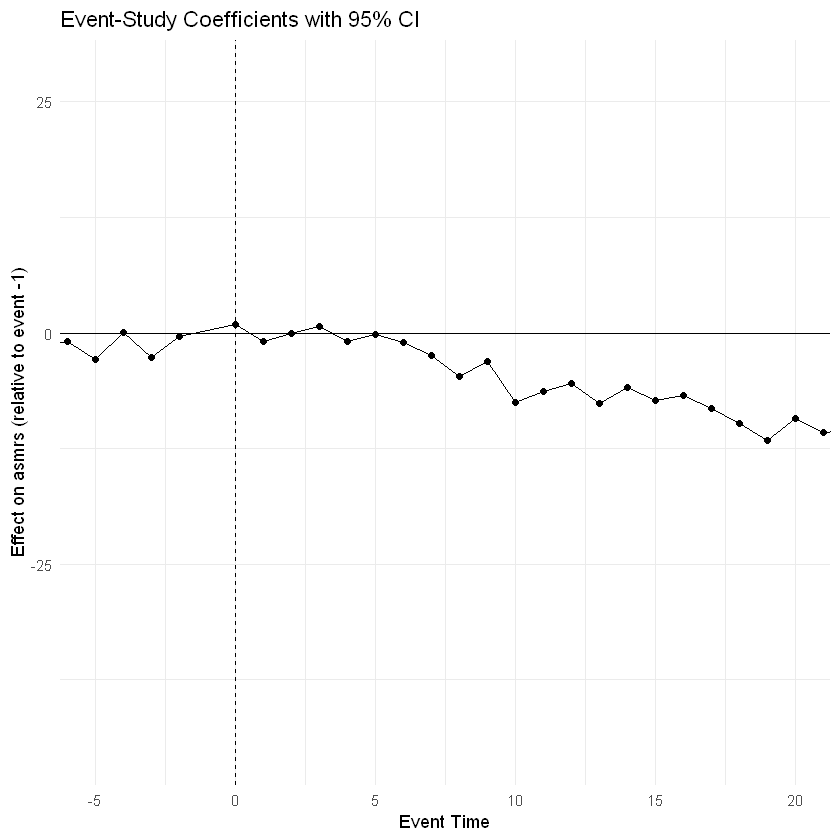

In [64]:
p_event